In [19]:
import sys
import importlib.metadata
import tensorflow as tf
import os
import gc
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input
from deepface import DeepFace
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.manifold import TSNE

In [20]:
if tf.config.list_physical_devices('GPU'):
    print("GPU is available.")
    physical_devices = tf.config.list_physical_devices('GPU')
    for device in physical_devices:
        print(f"Device: {device}")
        from tensorflow.python.client import device_lib
        local_device_protos = device_lib.list_local_devices()
        for device in local_device_protos:
            if device.device_type == 'GPU':
                print(f"Name: {device.name}")
                print(f"Memory Limit: {device.memory_limit / 1024 / 1024} MB")
else:
    print("No GPU available.")

GPU is available.
Device: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
Name: /device:GPU:0
Memory Limit: 3450.58984375 MB


In [21]:
packages = ["deepface", "opencv-python", "numpy", "matplotlib", 
            "scikit-learn", "tensorflow", "pandas", "seaborn"]

print(f"Python version: {sys.version}")

for pkg in packages:
    try:
        version = importlib.metadata.version(pkg)
        print(f"{pkg}: {version}")
    except importlib.metadata.PackageNotFoundError:
        print(f"{pkg}: Not found")

Python version: 3.10.19 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 16:41:31) [MSC v.1929 64 bit (AMD64)]
deepface: 0.0.96
opencv-python: 4.6.0.66
numpy: 1.23.5
matplotlib: 3.10.8
scikit-learn: 1.7.2
tensorflow: 2.10.0
pandas: 2.3.3
seaborn: 0.13.2


In [22]:
DATA_DIR = r"C:\Users\Yasindu\Desktop\Stuff\1.SLIIT\Research\Project\data\imgData\prepImg\step4"

In [23]:
IMG_SIZE = (224, 224) 
BATCH_SIZE = 32
SEED = 123 

In [24]:
# --- 2. Load the Dataset ---
# 80% Training
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

# 20% for Val and Test
remaining_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

# Final split for 10% Test / 10% Val
val_batches = tf.data.experimental.cardinality(remaining_ds)
test_ds = remaining_ds.take(val_batches // 2)
val_ds = remaining_ds.skip(val_batches // 2)

Found 3917 files belonging to 2 classes.
Using 3134 files for training.
Found 3917 files belonging to 2 classes.
Using 783 files for validation.


In [25]:
# --- 3. Combined Preprocessing (Normalization + Label Flip) ---
normalization_layer = tf.keras.layers.Rescaling(1./255)

def preprocess(x, y):
    # Normalize pixels to [0, 1]
    x = normalization_layer(x)
    # Flip labels so Autistic (alphabetically first, so 0) becomes 1
    y = 1 - y
    return x, y

train_ds = train_ds.map(preprocess)
val_ds = val_ds.map(preprocess)
test_ds = test_ds.map(preprocess)

# --- 4. Performance Optimization ---
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("\n--- Data Preparation Complete ---")
print("Confirmed: Autistic is now labeled 1, Non_Autistic is labeled 0.")


--- Data Preparation Complete ---
Confirmed: Autistic is now labeled 1, Non_Autistic is labeled 0.


In [26]:
for images, labels in train_ds.take(1):
    print(f"Sample Batch Labels: {labels.numpy().flatten()[:5]}")
    print(f"Pixel Max: {tf.reduce_max(images).numpy()}")

Sample Batch Labels: [0. 0. 0. 1. 0.]
Pixel Max: 1.0


In [27]:
# --- 1. Load the Pre-trained Backbone ---
vgg_model_wrapper = DeepFace.build_model("VGG-Face")
full_vgg_face = vgg_model_wrapper.model 

vgg_model_wrapper = DeepFace.build_model("VGG-Face")
full_vgg_face = vgg_model_wrapper.model 

# --- 2. Strip away the recognition layers ---
# Based on your error log, 'conv2d_14' is the final feature-rich layer.
backbone_output = full_vgg_face.get_layer("conv2d_14").output
feature_extractor = Model(inputs=full_vgg_face.input, outputs=backbone_output)

# --- 3. Freeze the Backbone Layers ---
feature_extractor.trainable = False

# --- 4. Attach the Custom Head ---
inputs = Input(shape=(224, 224, 3), name="face_input")


In [28]:
# Pass input through frozen backbone
# training=False is critical to keep the model in inference mode
x = feature_extractor(inputs, training=False)

# A. Global Average Pooling 
# This converts the 2D output of conv2d_14 into a 1D vector
x = GlobalAveragePooling2D()(x)

# B. Dense Layer (ASD Feature Learner)
feature_layer = Dense(256, activation='relu', name='asd_feature_vector')(x)

# C. Output Layer (Sigmoid for binary probability)
prediction = Dense(1, activation='sigmoid', name='classification_output')(feature_layer)

# --- 5. Build the Unified Model ---
# This meets your requirement for dual outputs (prediction + feature vector)
unified_model = Model(inputs=inputs, outputs=[prediction, feature_layer])

# Verify
unified_model.summary()

Model: "model_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 face_input (InputLayer)     [(None, 224, 224, 3)]     0         
                                                                 
 model_3 (Functional)        (None, 1, 1, 4096)        134260544 
                                                                 
 global_average_pooling2d_1   (None, 4096)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 asd_feature_vector (Dense)  (None, 256)               1048832   
                                                                 
 classification_output (Dens  (None, 1)                257       
 e)                                                              
                                                                 
Total params: 135,309,633
Trainable params: 1,049,089
Non-t

In [29]:
# Adjust datasets to handle the dual-output architecture
def map_for_dual_output(img, label):
    # The first 'label' is for classification_output
    # The second 'None' tells Keras not to calculate loss for the feature_vector output
    return img, {'classification_output': label, 'asd_feature_vector': label}

train_ds_final = train_ds.map(map_for_dual_output)
val_ds_final = val_ds.map(map_for_dual_output)
test_ds_final = test_ds.map(map_for_dual_output)

In [30]:
# Adjust datasets to handle the dual-output architecture
def map_for_dual_output(img, label):
    # The first 'label' is for classification_output
    # The second 'None' tells Keras not to calculate loss for the feature_vector output
    return img, {'classification_output': label, 'asd_feature_vector': label}

train_ds_final = train_ds.map(map_for_dual_output)
val_ds_final = val_ds.map(map_for_dual_output)
test_ds_final = test_ds.map(map_for_dual_output)

In [31]:
try:
    # Test a single dummy prediction to ensure the "Dual Output" works
    dummy_input = tf.random.uniform((1, 224, 224, 3))
    pred, feat = unified_model.predict(dummy_input)
    print(f"Prediction Output Shape: {pred.shape}") # Should be (1, 1)
    print(f"Feature Vector Shape: {feat.shape}")    # Should be (1, 256)
    print("\n✅ CHECKLIST PASSED: Architecture and Data are aligned.")
except Exception as e:
    print(f"\n❌ CHECKLIST FAILED: {e}")

1/1 [==============================] - 0s 168ms/step
Prediction Output Shape: (1, 1)
Feature Vector Shape: (1, 256)

✅ CHECKLIST PASSED: Architecture and Data are aligned.


In [32]:
# 1. Define the Optimizer
# Adam is used as it's highly efficient for transfer learning
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)

# 2. Compile the Unified Model
unified_model.compile(
    optimizer=optimizer,
    # We define loss for the classification output only
    # The feature vector output is for extraction, not for direct optimization
    loss={
        'classification_output': 'binary_crossentropy',
        'asd_feature_vector': None 
    },
    # We track Accuracy, Precision, and Recall for the classification branch
    metrics={
        'classification_output': [
            'accuracy', 
            tf.keras.metrics.Precision(name='precision'), 
            tf.keras.metrics.Recall(name='recall')
        ]
    }
)

print("--- Step 3: Model Compilation Complete ---")
unified_model.summary()

--- Step 3: Model Compilation Complete ---
Model: "model_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 face_input (InputLayer)     [(None, 224, 224, 3)]     0         
                                                                 
 model_3 (Functional)        (None, 1, 1, 4096)        134260544 
                                                                 
 global_average_pooling2d_1   (None, 4096)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 asd_feature_vector (Dense)  (None, 256)               1048832   
                                                                 
 classification_output (Dens  (None, 1)                257       
 e)                                                              
                                                                 
Total params: 13

In [33]:
# Function to align dataset labels with the multi-output model architecture
def prepare_for_training(img, label):
    # We pass the same label to both output keys so the model knows where to look
    return img, {'classification_output': label, 'asd_feature_vector': label}

# Apply the mapping to all dataset splits
train_ds_final = train_ds.map(prepare_for_training)
val_ds_final = val_ds.map(prepare_for_training)
test_ds_final = test_ds.map(prepare_for_training)

print("Datasets are now configured for Dual-Output Training.")

Datasets are now configured for Dual-Output Training.


In [34]:
# 1. Define Callbacks
# Stop if validation loss doesn't improve for 5 consecutive epochs
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True,
    verbose=1
)

In [35]:
# Save the best model weights based on highest validation accuracy
checkpoint_path = r"C:\Users\Yasindu\Desktop\Stuff\1.SLIIT\Research\Project\best_asd_model6.h5"
checkpoint = ModelCheckpoint(
    checkpoint_path, 
    monitor='val_accuracy', 
    save_best_only=True, 
    mode='max',
    verbose=1
)

In [36]:
# 2. Start the Training Process
# We use 20 epochs
print("Starting Training...")
history = unified_model.fit(
    train_ds_final,
    validation_data=val_ds_final,
    epochs=20,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

Starting Training...
Epoch 1/20
98/98 [==============================] - 31s 308ms/step - loss: 0.6789 - classification_output_loss: 0.6789 - classification_output_accuracy: 0.6327 - classification_output_precision: 0.7365 - classification_output_recall: 0.4163 - val_loss: 0.6606 - val_classification_output_loss: 0.6606 - val_classification_output_accuracy: 0.6817 - val_classification_output_precision: 0.7273 - val_classification_output_recall: 0.5941
Epoch 2/20
98/98 [==============================] - 29s 298ms/step - loss: 0.6363 - classification_output_loss: 0.6363 - classification_output_accuracy: 0.7084 - classification_output_precision: 0.7529 - classification_output_recall: 0.6225 - val_loss: 0.6180 - val_classification_output_loss: 0.6180 - val_classification_output_accuracy: 0.7268 - val_classification_output_precision: 0.7313 - val_classification_output_recall: 0.7277
Epoch 3/20
98/98 [==============================] - 29s 299ms/step - loss: 0.5955 - classification_output_los

In [37]:
print("Extending Training to 35 Epochs...")

history_extension = unified_model.fit(
    train_ds_final,
    validation_data=val_ds_final,
    epochs=15, # This adds 15 to your current 20
    callbacks=[early_stop, checkpoint]
)

Extending Training to 35 Epochs...
Epoch 1/15
98/98 [==============================] - 30s 303ms/step - loss: 0.3566 - classification_output_loss: 0.3566 - classification_output_accuracy: 0.8561 - classification_output_precision: 0.8608 - classification_output_recall: 0.8504 - val_loss: 0.4525 - val_classification_output_loss: 0.4525 - val_classification_output_accuracy: 0.7995 - val_classification_output_precision: 0.7990 - val_classification_output_recall: 0.8069
Epoch 2/15
98/98 [==============================] - 29s 301ms/step - loss: 0.3491 - classification_output_loss: 0.3491 - classification_output_accuracy: 0.8583 - classification_output_precision: 0.8624 - classification_output_recall: 0.8536 - val_loss: 0.4520 - val_classification_output_loss: 0.4520 - val_classification_output_accuracy: 0.7945 - val_classification_output_precision: 0.8030 - val_classification_output_recall: 0.7871
Epoch 3/15
98/98 [==============================] - 29s 299ms/step - loss: 0.3434 - classificat

In [38]:
print("Cleaning up GPU memory...")
tf.keras.backend.clear_session()
gc.collect()

Cleaning up GPU memory...


5045

In [39]:
NEW_BATCH_SIZE = 16

In [40]:
train_ds_low_mem = train_ds.unbatch().batch(NEW_BATCH_SIZE).map(prepare_for_training)
val_ds_low_mem = val_ds.unbatch().batch(NEW_BATCH_SIZE).map(prepare_for_training)

In [41]:
# --- STEP 3: PARTIAL UNFREEZING ---
# We unfreeze only the last block of VGG-Face (the high-level features)
feature_extractor.trainable = True

# Freeze everything EXCEPT the last 4 layers of the backbone
for layer in feature_extractor.layers[:-4]:
    layer.trainable = False

print(f"Backbone unfrozen for final {len(feature_extractor.layers[-4:])} layers.")

Backbone unfrozen for final 4 layers.


In [42]:
# --- STEP 4: RE-COMPILE WITH ULTRA-LOW LEARNING RATE ---
# Use 1e-5 (0.00001) to delicately tune the pre-trained weights
unified_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss={'classification_output': 'binary_crossentropy'},
    metrics={'classification_output': ['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]}
)

In [43]:
# --- STEP 5: RUN FINE-TUNING ---
print("Starting Phase 2: Specialist Fine-Tuning...")
history_fine = unified_model.fit(
    train_ds_low_mem,
    validation_data=val_ds_low_mem,
    epochs=10, 
    callbacks=[early_stop, checkpoint]
)

Starting Phase 2: Specialist Fine-Tuning...
Epoch 1/10
196/196 [==============================] - 53s 244ms/step - loss: 0.2715 - classification_output_loss: 0.2715 - classification_output_accuracy: 0.8902 - classification_output_precision: 0.8940 - classification_output_recall: 0.8861 - val_loss: 0.3942 - val_classification_output_loss: 0.3942 - val_classification_output_accuracy: 0.8446 - val_classification_output_precision: 0.8302 - val_classification_output_recall: 0.8713
Epoch 2/10
196/196 [==============================] - 43s 218ms/step - loss: 0.0777 - classification_output_loss: 0.0777 - classification_output_accuracy: 0.9872 - classification_output_precision: 0.9923 - classification_output_recall: 0.9822 - val_loss: 0.3995 - val_classification_output_loss: 0.3995 - val_classification_output_accuracy: 0.8421 - val_classification_output_precision: 0.8458 - val_classification_output_recall: 0.8416
Epoch 3/10
196/196 [==============================] - 49s 248ms/step - loss: 0.030

In [44]:
tf.keras.backend.clear_session()
gc.collect()

488

In [45]:
# 2. Re-batch the Test Dataset to a smaller size (8)
test_ds_low_mem = test_ds.unbatch().batch(8).map(prepare_for_training)

print("Evaluating on Test Dataset with low-memory configuration...")

Evaluating on Test Dataset with low-memory configuration...


48/48 [==============================] - 9s 119ms/step - loss: 0.4630 - classification_output_loss: 0.4630 - classification_output_accuracy: 0.8151 - classification_output_precision: 0.7868 - classification_output_recall: 0.8424

Test Accuracy: 46.30%
Test Precision: 81.51%
Test Recall: 78.68%

Generating Confusion Matrix data...


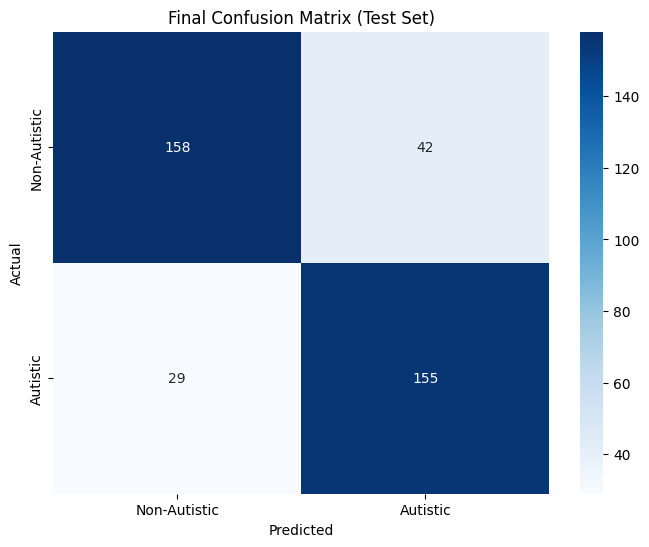


--- Final Classification Report ---
              precision    recall  f1-score   support

Non-Autistic       0.84      0.79      0.82       200
    Autistic       0.79      0.84      0.81       184

    accuracy                           0.82       384
   macro avg       0.82      0.82      0.82       384
weighted avg       0.82      0.82      0.82       384



In [46]:
# 3. Perform Evaluation
evaluation_results = unified_model.evaluate(test_ds_low_mem)
print(f"\nTest Accuracy: {evaluation_results[1]*100:.2f}%")
print(f"Test Precision: {evaluation_results[2]*100:.2f}%")
print(f"Test Recall: {evaluation_results[3]*100:.2f}%")

# 4. Get Predictions for the Confusion Matrix
y_true = []
y_pred = []

print("\nGenerating Confusion Matrix data...")
for images, labels in test_ds_low_mem:
    true_labels = labels['classification_output'].numpy().flatten()
    # We use verbose=0 to keep the console clean
    preds, _ = unified_model.predict(images, verbose=0)
    
    y_true.extend(true_labels)
    y_pred.extend((preds > 0.5).astype(int).flatten())

# 5. Visualize
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-Autistic', 'Autistic'], 
            yticklabels=['Non-Autistic', 'Autistic'])
plt.title('Final Confusion Matrix (Test Set)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print("\n--- Final Classification Report ---")
print(classification_report(y_true, y_pred, target_names=['Non-Autistic', 'Autistic']))

Extracting feature vectors for visualization...


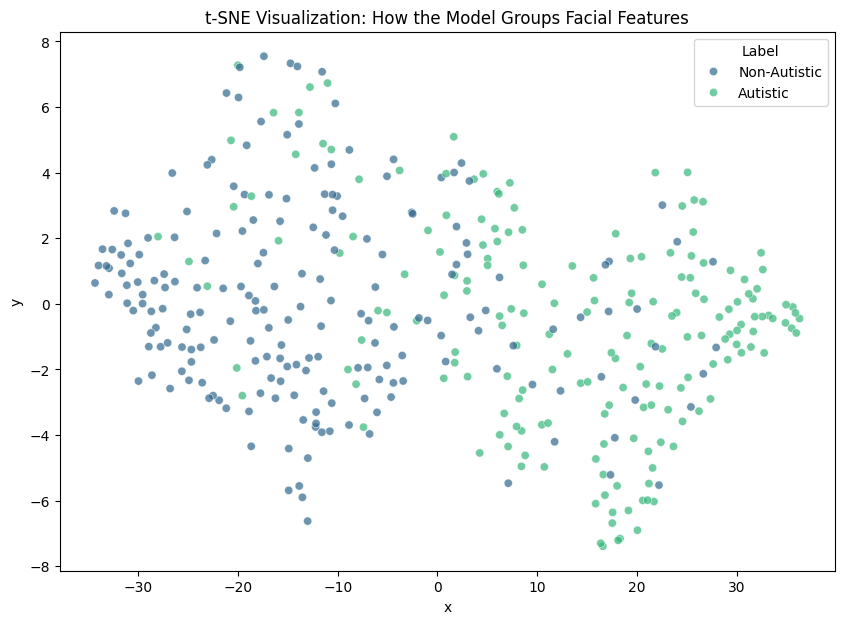

In [47]:
# 1. Extract features from the test set
print("Extracting feature vectors for visualization...")
all_features = []
all_labels = []

for images, labels in test_ds_low_mem:
    # Use the second output of our unified model
    _, features = unified_model.predict(images, verbose=0)
    all_features.append(features)
    all_labels.extend(labels['classification_output'].numpy().flatten())

all_features = np.concatenate(all_features, axis=0)
all_labels = np.array(all_labels)

# 2. Run t-SNE (Reduces 256D down to 2D for plotting)
tsne = TSNE(n_components=2, random_state=SEED)
low_dim_features = tsne.fit_transform(all_features)

# 3. Plot the Clusters
plt.figure(figsize=(10, 7))
df = pd.DataFrame({
    'x': low_dim_features[:, 0],
    'y': low_dim_features[:, 1],
    'Label': ['Autistic' if l == 1 else 'Non-Autistic' for l in all_labels]
})

sns.scatterplot(data=df, x='x', y='y', hue='Label', palette='viridis', alpha=0.7)
plt.title('t-SNE Visualization: How the Model Groups Facial Features')
plt.show()



In [56]:
# Save the final model for deployment
model_save_path = r"C:\Users\Yasindu\Desktop\Stuff\1.SLIIT\Research\Project\models\model_1.h5"
unified_model.save(model_save_path)

print(f"Project Complete! Model saved to: {model_save_path}")

Project Complete! Model saved to: C:\Users\Yasindu\Desktop\Stuff\1.SLIIT\Research\Project\models\model_1.h5


In [53]:
import shutil
import os

# 1. Define destination
DEST_TEST_DIR = r"C:\Users\Yasindu\Desktop\Stuff\1.SLIIT\Research\Project\ModelTestingIMGS\model1"

# 2. Get the paths from the original remaining_ds before it was prefetched
# Since test_ds = remaining_ds.take(val_batches // 2)
all_paths = remaining_ds.file_paths
num_test_files = (val_batches // 2).numpy() * BATCH_SIZE 
# Note: we use the number of samples to slice the list of paths
test_paths = all_paths[:num_test_files]

print(f"Recovered {len(test_paths)} file paths.")
print(f"Starting copy...")

files_copied = 0
for path in test_paths:
    class_name = os.path.basename(os.path.dirname(path))
    target_dir = os.path.join(DEST_TEST_DIR, class_name)
    
    if not os.path.exists(target_dir):
        os.makedirs(target_dir)
    
    shutil.copy(path, os.path.join(target_dir, os.path.basename(path)))
    files_copied += 1

print(f"\n✅ SUCCESS! Copied {files_copied} images to {DEST_TEST_DIR}")

Recovered 384 file paths.
Starting copy...

✅ SUCCESS! Copied 384 images to C:\Users\Yasindu\Desktop\Stuff\1.SLIIT\Research\Project\model1
